# Documents

In [1]:
documents = [
    {
        "id": "doc1",
        "text": "Camera CAM-01 detected a person entering the restricted storage area at 22:14."
    },
    {
        "id": "doc2",
        "text": "Motor A17 stopped because the power supply voltage dropped below the safe operating level."
    },
    {
        "id": "doc3",
        "text": "Error code E104 indicates a voltage failure in the motor controller."
    },
    {
        "id": "doc4",
        "text": "The cooling fan was blocked by dust, causing the device to overheat."
    },
    {
        "id": "doc5",
        "text": "CAM-03 recorded two workers entering Zone B during normal operating hours."
    },
    {
        "id": "doc6",
        "text": "Repeated overheating can be caused by poor airflow, fan failure, or excessive load."
    },
    {
        "id": "doc7",
        "text": "Device INV-2026-001 requires inspection after 500 operating hours."
    },
    {
        "id": "doc8",
        "text": "An unauthorized individual crossed the security boundary near warehouse entrance 2."
    },
    {
        "id": "doc9",
        "text": "Motor A17 should be shut down immediately if temperature exceeds 90 degrees Celsius."
    },
    {
        "id": "doc10",
        "text": "Camera CAM-07 lost network connectivity for approximately twelve minutes."
    },
]

# 1. Dense / Vector Retrieval

In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np
from huggingface_hub import login
from dotenv import load_dotenv
import os

In [7]:
load_dotenv()

True

In [9]:
login(
    token= os.getenv("HF_TOKEN"),
    add_to_git_credential=True
)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [10]:
embedding_model = "all-MiniLM-L6-v2"
embedding = SentenceTransformer(embedding_model)

Loading weights: 100%|█████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 6002.94it/s]


## Create document embeddings

In [12]:
texts = [doc["text"] for doc in documents]

In [14]:
embedded_docs = embedding.encode(texts, normalize_embeddings=True)

In [20]:
# (10, 384) refers to the shape of embedded documents -- meaning 10 docs * 384 numeric dimensions per document
print(embedded_docs.shape)

(10, 384)


In [25]:
print(embedded_docs[9])

[-1.60051917e-03 -1.51494769e-02  3.74866948e-02  4.48917449e-02
  4.65935953e-02  3.68583836e-02 -5.50871482e-03  6.18234091e-02
  1.56734642e-02  3.41922380e-02  4.81563732e-02  7.87349269e-02
 -5.67675196e-02  2.47563217e-02  4.55104262e-02 -4.81572971e-02
 -1.04791746e-02 -8.97715837e-02 -4.15415503e-02 -3.36618628e-03
 -4.73163426e-02 -5.69781885e-02  4.69899215e-02 -9.95447277e-04
  9.06401202e-02 -5.05054668e-02  3.85138504e-02  5.63102216e-03
 -1.65086798e-02  2.74517871e-02 -7.12552294e-02  1.98786426e-02
 -5.66970669e-02 -2.06015003e-03  6.30802661e-02 -6.99906871e-02
  3.57997902e-02  2.85946336e-02 -1.62752140e-02 -2.46094037e-02
 -3.44214626e-02  1.37985330e-02  4.93576713e-02  1.94787153e-03
  1.25177735e-02  4.84976396e-02  6.08294792e-02 -3.86107937e-02
  5.47678918e-02 -8.34221989e-02 -3.66592109e-02  8.03211331e-02
 -1.12446491e-02 -6.05794834e-03  1.97359975e-02  1.79942567e-02
 -8.14021751e-02 -2.17437968e-02 -1.14047220e-02  2.86222454e-02
  3.94758210e-02 -1.32811

## 2. Embed a query

In [26]:
query = "Someone entered an area where they were not allowed."

In [27]:
embedded_query = embedding.encode(query, normalize_embeddings=True)

In [30]:
embedded_query.shape

(384,)

## Calculate similarity manually

In [40]:
### dot product example ###

document = [1, 2, 3]
query    = [1, 2, 3]

dot_product = sum(x * y for x, y in zip(document, query)) 
dot_product

14

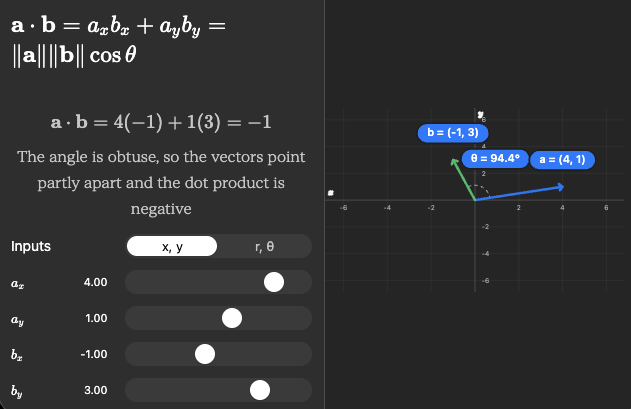

In [51]:
scores = embedded_docs @ embedded_query

In [52]:
scores

array([ 0.4845683 ,  0.1960743 ,  0.10900685,  0.06959274,  0.32394394,
       -0.0152393 ,  0.15101582,  0.5553091 ,  0.03009672,  0.15402576],
      dtype=float32)

In [53]:
scores.shape

(10,)

In [57]:
scores.argmax()

np.int64(7)

In [58]:
scores.max()

np.float32(0.5553091)

## Understand the relationship between indices and documents

In [59]:
for i, score in enumerate(scores): 
    print(
        documents[i]["id"], 
        score, 
        documents[i]["text"]
    )

doc1 0.4845683 Camera CAM-01 detected a person entering the restricted storage area at 22:14.
doc2 0.1960743 Motor A17 stopped because the power supply voltage dropped below the safe operating level.
doc3 0.10900685 Error code E104 indicates a voltage failure in the motor controller.
doc4 0.069592744 The cooling fan was blocked by dust, causing the device to overheat.
doc5 0.32394394 CAM-03 recorded two workers entering Zone B during normal operating hours.
doc6 -0.015239302 Repeated overheating can be caused by poor airflow, fan failure, or excessive load.
doc7 0.15101582 Device INV-2026-001 requires inspection after 500 operating hours.
doc8 0.5553091 An unauthorized individual crossed the security boundary near warehouse entrance 2.
doc9 0.030096719 Motor A17 should be shut down immediately if temperature exceeds 90 degrees Celsius.
doc10 0.15402576 Camera CAM-07 lost network connectivity for approximately twelve minutes.
